In [1]:
# =============================================================
# CELL 1 — IMPORTS
# =============================================================

import os
import glob
import json
import hashlib
import wave
import warnings
import ast
import re

from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# =============================================================
# CELL 2 — PROJECT CONFIGURATION
# =============================================================

BASE_DIR = os.path.abspath(r'C:\New folder\New Emodect\datasets')
CONFIG_DIR = os.path.abspath(r'C:\New folder\New Emodect\config')
REPORTS_DIR = os.path.abspath(r'C:\New folder\New Emodect\reports')

PLOTS_DIR = os.path.join(
    REPORTS_DIR,
    'plots'
)

INSPECTION_DIR = os.path.join(
    REPORTS_DIR,
    'inspection'
)

LOG_DIR = os.path.join(
    REPORTS_DIR,
    'logs'
)

for directory in [
    CONFIG_DIR,
    REPORTS_DIR,
    PLOTS_DIR,
    INSPECTION_DIR,
    LOG_DIR
]:
    os.makedirs(
        directory,
        exist_ok=True
    )


print("BASE_DIR    :", BASE_DIR)
print("CONFIG_DIR  :", CONFIG_DIR)
print("REPORTS_DIR :", REPORTS_DIR)

BASE_DIR    : C:\New folder\New Emodect\datasets
CONFIG_DIR  : C:\New folder\New Emodect\config
REPORTS_DIR : C:\New folder\New Emodect\reports


In [3]:
# =============================================================
# CELL 3 — CANONICAL EMOTION TAXONOMY
# =============================================================

CANONICAL_EMOTIONS = [
    "anger",
    "disgust",
    "fear",
    "happiness",
    "sadness",
    "surprise",
    "neutral"
]

CANONICAL_EMOTION_SET = set(
    CANONICAL_EMOTIONS
)

print("Canonical seven-class target:")
for i, emotion in enumerate(
    CANONICAL_EMOTIONS,
    start=1
):
    print(f"{i}. {emotion}")

Canonical seven-class target:
1. anger
2. disgust
3. fear
4. happiness
5. sadness
6. surprise
7. neutral


In [4]:
# =============================================================
# CELL 4 — LABEL DESIGN DECISIONS
# =============================================================

# -------------------------------------------------------------
# RAVDESS
# -------------------------------------------------------------
#
# True:
#     RAVDESS "calm" is harmonized to canonical "neutral".
#
# False:
#     RAVDESS "calm" is NOT used for the seven-class target.
#
# This is an explicit taxonomy decision.
# It is NOT a generic alias.
# -------------------------------------------------------------

RAVDESS_CALM_TO_NEUTRAL = True


# -------------------------------------------------------------
# IEMOCAP
# -------------------------------------------------------------
#
# IEMOCAP "exc" is treated as happiness.
# This is also an explicit harmonization decision.
# -------------------------------------------------------------

IEMOCAP_EXC_TO_HAPPINESS = True


print(
    "RAVDESS calm → neutral:",
    RAVDESS_CALM_TO_NEUTRAL
)

print(
    "IEMOCAP excited → happiness:",
    IEMOCAP_EXC_TO_HAPPINESS
)

RAVDESS calm → neutral: True
IEMOCAP excited → happiness: True


In [5]:
# =============================================================
# CELL 5 — LOAD EXISTING EMOTION MAP
# =============================================================

EMOTION_MAP_PATH = os.path.join(
    CONFIG_DIR,
    'emotion_map.json'
)

if os.path.exists(
    EMOTION_MAP_PATH
):

    with open(
        EMOTION_MAP_PATH,
        'r',
        encoding='utf-8'
    ) as f:

        EMOTION_MAP = json.load(f)

    print(
        "Loaded:",
        EMOTION_MAP_PATH
    )

else:

    print(
        "WARNING: emotion_map.json was not found."
    )

    EMOTION_MAP = {}

Loaded: C:\New folder\New Emodect\config\emotion_map.json


In [6]:
# =============================================================
# CELL 6 — DATASET CONFIGURATION (FINAL ACTIVE DATASETS)
# =============================================================
#
# Active emotion datasets:
#   CREMA-D, RAVDESS, SAVEE, TESS, IEMOCAP,
#   FER2013, AffectNet, CK+, RAF-DB, GoEmotions
#
# SAMM is archived/optional and is intentionally NOT part of
# active static verification.
# =============================================================

def resolve_dataset_root(candidates, required_markers=None):
    required_markers = required_markers or []

    for candidate in candidates:
        if not os.path.isdir(candidate):
            continue
        if all(
            os.path.exists(os.path.join(candidate, marker))
            for marker in required_markers
        ):
            return os.path.abspath(candidate)

    basename_targets = {
        os.path.basename(os.path.normpath(c)).lower()
        for c in candidates
    }

    for root, dirs, files in os.walk(BASE_DIR):
        if os.path.basename(root).lower() not in basename_targets:
            continue
        if all(
            os.path.exists(os.path.join(root, marker))
            for marker in required_markers
        ):
            return os.path.abspath(root)

    return None


# -----------------------------
# IEMOCAP
# -----------------------------
IEMOCAP_ROOT = resolve_dataset_root(
    [
        os.path.join(
            BASE_DIR, 'dejolilandry', 'iemocapfullrelease',
            'versions', '1', 'IEMOCAP_fullrelease'
        ),
        os.path.join(
            BASE_DIR, 'dejolilandry', 'iemocapfullrelease',
            'versions', '1', 'IEMOCAP_full_release'
        ),
        os.path.join(
            BASE_DIR, 'dejolilandry', 'iemocapfullrelease'
        ),
    ],
    required_markers=['Session1']
)

if IEMOCAP_ROOT is None:
    for root, dirs, files in os.walk(BASE_DIR):
        if 'Session1' not in dirs:
            continue

        eval_dirs = glob.glob(
            os.path.join(root, '**', 'EmoEvaluation'),
            recursive=True
        )

        if eval_dirs:
            IEMOCAP_ROOT = os.path.abspath(root)
            break

if IEMOCAP_ROOT is None:
    raise FileNotFoundError(
        "IEMOCAP release root could not be resolved."
    )


# -----------------------------
# TESS
# -----------------------------
# Prefer the actual inner TESS data directory. The parent Kaggle
# extraction directory may contain two copies of the WAV tree and
# therefore incorrectly reports 5,600 files instead of 2,800.
TESS_ROOT = resolve_dataset_root(
    [
        os.path.join(
            BASE_DIR, 'ejlok1',
            'toronto-emotional-speech-set-tess',
            'versions', '1',
            'TESS Toronto emotional speech set data',
            'TESS Toronto emotional speech set data'
        ),
        os.path.join(
            BASE_DIR, 'ejlok1',
            'toronto-emotional-speech-set-tess',
            'TESS Toronto emotional speech set data',
            'TESS Toronto emotional speech set data'
        ),
        os.path.join(
            BASE_DIR, 'ejlok1',
            'toronto-emotional-speech-set-tess',
            'TESS Toronto emotional speech set data'
        ),
    ],
    required_markers=['OAF_angry']
)

if TESS_ROOT is None:
    # Structural fallback: choose a TESS directory containing the
    # characteristic OAF/YAF emotion folders, preferring the
    # deepest matching directory.
    tess_candidates = []

    for root, dirs, files in os.walk(
        os.path.join(BASE_DIR, 'ejlok1')
    ):
        dirset = {d.lower() for d in dirs}

        if {'oaf_angry', 'yaf_angry'}.issubset(dirset):
            wav_count = len(
                glob.glob(
                    os.path.join(root, '**', '*.wav'),
                    recursive=True
                )
            )
            tess_candidates.append(
                (root, wav_count)
            )

    if tess_candidates:
        # Prefer the candidate with the smaller valid TESS tree when
        # nested parent/child copies both exist.
        tess_candidates.sort(
            key=lambda x: (
                0 if x[1] == 2800 else 1,
                x[1],
                -len(os.path.normpath(x[0]).split(os.sep))
            )
        )
        TESS_ROOT = os.path.abspath(
            tess_candidates[0][0]
        )

if TESS_ROOT is None:
    raise FileNotFoundError(
        "TESS root could not be resolved."
    )


# -----------------------------
# GoEmotions
# -----------------------------
GOEMOTIONS_ROOT = resolve_dataset_root(
    [
        os.path.join(
            BASE_DIR, 'debarshichanda', 'goemotions',
            'versions', '6', 'data', 'full_dataset'
        ),
        os.path.join(
            BASE_DIR, 'debarshichanda', 'goemotions',
            'versions', '6', 'data'
        ),
        os.path.join(
            BASE_DIR, 'debarshichanda', 'goemotions'
        ),
    ]
)

if GOEMOTIONS_ROOT is None:
    raise FileNotFoundError(
        "GoEmotions root could not be resolved."
    )


datasets_to_verify = {

    'CREMA-D': {
        'path': os.path.join(BASE_DIR, 'AudioWAV'),
        'type': 'audio',
        'format': ['**/*.wav']
    },

    'RAVDESS': {
        'path': os.path.join(BASE_DIR, 'RAVDESS_Dataset'),
        'type': 'mixed',
        'format': [
            '**/*.wav',
            '**/*.mp4',
            '**/*.avi',
            '**/*.mov'
        ]
    },

    'SAVEE': {
        'path': os.path.join(
            BASE_DIR,
            'ejlok1',
            'surrey-audiovisual-expressed-emotion-savee'
        ),
        'type': 'audio',
        'format': ['**/*.wav']
    },

    'TESS': {
        'path': TESS_ROOT,
        'type': 'audio',
        'format': ['**/*.wav']
    },

    'IEMOCAP': {
        'path': IEMOCAP_ROOT,
        'type': 'mixed',
        'format': [
            '**/*.wav',
            '**/*.mp4',
            '**/*.avi',
            '**/*.mov'
        ]
    },

    'FER2013': {
        'path': os.path.join(
            BASE_DIR, 'msambare', 'fer2013'
        ),
        'type': 'image',
        'format': ['**/*.jpg', '**/*.png']
    },

    'AffectNet': {
        'path': os.path.join(
            BASE_DIR, 'mstjebashazida', 'affectnet'
        ),
        'type': 'image',
        'format': ['**/*.jpg', '**/*.png']
    },

    'CK+': {
        'path': os.path.join(
            BASE_DIR, 'shawon10', 'ckplus'
        ),
        'type': 'image',
        'format': ['**/*.jpg', '**/*.png']
    },

    'RAF-DB': {
        'path': os.path.join(
            BASE_DIR, 'shuvoalok', 'raf-db-dataset'
        ),
        'type': 'image',
        'format': ['**/*.jpg', '**/*.png']
    },

    'GoEmotions': {
        'path': GOEMOTIONS_ROOT,
        'type': 'text',
        'format': ['**/*.csv']
    }
}

assert 'SAMM' not in datasets_to_verify
assert len(datasets_to_verify) == 10

print(f"{len(datasets_to_verify)} active emotion datasets configured.")
print("IEMOCAP root   :", IEMOCAP_ROOT)
print("TESS root      :", TESS_ROOT)
print("GoEmotions root:", GOEMOTIONS_ROOT)


10 active emotion datasets configured.
IEMOCAP root   : C:\New folder\New Emodect\datasets\dejolilandry\iemocapfullrelease\versions\1\IEMOCAP_full_release
TESS root      : C:\New folder\New Emodect\datasets\ejlok1\toronto-emotional-speech-set-tess\versions\1\TESS Toronto emotional speech set data\TESS Toronto emotional speech set data
GoEmotions root: C:\New folder\New Emodect\datasets\debarshichanda\goemotions\versions\6\data\full_dataset


In [7]:
# =============================================================
# CELL 7 — FINAL DATASET-SPECIFIC LABEL HARMONIZATION
# =============================================================

DATASET_LABEL_MAP = {

    # =========================================================
    # CREMA-D
    # =========================================================
    # CREMA-D provides:
    # ANG, DIS, FEA, HAP, SAD, NEU
    #
    # No SURPRISE source class is assumed.
    # =========================================================

    'CREMA-D': {
        'ANG': 'anger',
        'DIS': 'disgust',
        'FEA': 'fear',
        'HAP': 'happiness',
        'SAD': 'sadness',
        'NEU': 'neutral'
    },


    # =========================================================
    # RAVDESS
    # =========================================================

    'RAVDESS': {
        '01': 'neutral',
        '02': (
            'neutral'
            if RAVDESS_CALM_TO_NEUTRAL
            else None
        ),
        '03': 'happiness',
        '04': 'sadness',
        '05': 'anger',
        '06': 'fear',
        '07': 'disgust',
        '08': 'surprise'
    },


    # =========================================================
    # SAVEE
    # =========================================================

    'SAVEE': {
        'A': 'anger',
        'D': 'disgust',
        'F': 'fear',
        'H': 'happiness',
        'N': 'neutral',
        'SA': 'sadness',
        'SU': 'surprise'
    },


    # =========================================================
    # TESS
    # =========================================================

    'TESS': {
        'ANGER': 'anger',
        'ANGRY': 'anger',

        'DISGUST': 'disgust',
        'DISGUSTED': 'disgust',

        'FEAR': 'fear',
        'FEARFUL': 'fear',

        'HAPPY': 'happiness',
        'HAPPINESS': 'happiness',

        'SAD': 'sadness',
        'SADNESS': 'sadness',

        'SURPRISE': 'surprise',
        'SURPRISED': 'surprise',

        'PLEASANT_SURPRISE': 'surprise',
        'PLEASANT_SURPRISED': 'surprise',

        'NEUTRAL': 'neutral'
    },


    # =========================================================
    # IEMOCAP
    # =========================================================

    'IEMOCAP': {
        'ANG': 'anger',
        'DIS': 'disgust',
        'FEA': 'fear',
        'HAP': 'happiness',
        'SAD': 'sadness',
        'SUR': 'surprise',
        'NEU': 'neutral',

        'EXC': (
            'happiness'
            if IEMOCAP_EXC_TO_HAPPINESS
            else None
        )
    },


    # =========================================================
    # FER2013
    # =========================================================

    'FER2013': {
        '0': 'anger',
        '1': 'disgust',
        '2': 'fear',
        '3': 'happiness',
        '4': 'sadness',
        '5': 'surprise',
        '6': 'neutral',

        'ANGER': 'anger',
        'ANGRY': 'anger',
        'DISGUST': 'disgust',
        'DISGUSTED': 'disgust',
        'FEAR': 'fear',
        'FEARFUL': 'fear',
        'HAPPY': 'happiness',
        'HAPPINESS': 'happiness',
        'SAD': 'sadness',
        'SADNESS': 'sadness',
        'SURPRISE': 'surprise',
        'SURPRISED': 'surprise',
        'NEUTRAL': 'neutral'
    },


    # =========================================================
    # AffectNet
    # =========================================================

    'AffectNet': {
        'ANGER': 'anger',
        'DISGUST': 'disgust',
        'FEAR': 'fear',
        'HAPPINESS': 'happiness',
        'HAPPY': 'happiness',
        'SADNESS': 'sadness',
        'SAD': 'sadness',
        'SURPRISE': 'surprise',
        'NEUTRAL': 'neutral'
    },


    # =========================================================
    # CK+
    # =========================================================

    'CK+': {
        'ANGER': 'anger',
        'DISGUST': 'disgust',
        'FEAR': 'fear',
        'HAPPINESS': 'happiness',
        'HAPPY': 'happiness',
        'SADNESS': 'sadness',
        'SAD': 'sadness',
        'SURPRISE': 'surprise',
        'NEUTRAL': 'neutral'
    },


    # =========================================================
    # RAF-DB
    # =========================================================

    'RAF-DB': {
        '1': 'surprise',
        '2': 'fear',
        '3': 'disgust',
        '4': 'happiness',
        '5': 'sadness',
        '6': 'anger',
        '7': 'neutral'
    },


    # =========================================================
    # GOEMOTIONS
    # =========================================================

    # Conservative mapping only.
    # Ambiguous semantic categories remain excluded.

    'GoEmotions': {

        'AMUSEMENT': 'happiness',
        'EXCITEMENT': 'happiness',
        'JOY': 'happiness',
        'LOVE': 'happiness',

        'ANGER': 'anger',
        'ANNOYANCE': 'anger',
        'DISAPPROVAL': 'anger',

        'SADNESS': 'sadness',
        'DISAPPOINTMENT': 'sadness',
        'GRIEF': 'sadness',
        'REMORSE': 'sadness',

        'FEAR': 'fear',
        'NERVOUSNESS': 'fear',

        'DISGUST': 'disgust',

        'SURPRISE': 'surprise',

        'NEUTRAL': 'neutral'
    }
}


print("FINAL dataset-specific mappings loaded.")

FINAL dataset-specific mappings loaded.


In [8]:
# =============================================================
# CELL 8 — GENERAL UTILITIES + GOEMOTIONS LABEL DECODING
# =============================================================

def normalize_raw_label(label):
    if label is None:
        return None

    try:
        if pd.isna(label):
            return None
    except (TypeError, ValueError):
        pass

    text = str(label).strip()

    if not text:
        return None

    return text.upper()


def map_dataset_label(dataset_name, raw_label):
    normalized = normalize_raw_label(raw_label)

    return DATASET_LABEL_MAP.get(
        dataset_name,
        {}
    ).get(
        normalized,
        None
    )


def is_canonical_emotion(label):
    return label in CANONICAL_EMOTION_SET


# Standard GoEmotions label IDs.
GOEMOTIONS_ID_TO_NAME = {
    0: 'admiration',
    1: 'amusement',
    2: 'anger',
    3: 'annoyance',
    4: 'approval',
    5: 'caring',
    6: 'confusion',
    7: 'curiosity',
    8: 'desire',
    9: 'disappointment',
    10: 'disapproval',
    11: 'disgust',
    12: 'embarrassment',
    13: 'excitement',
    14: 'fear',
    15: 'gratitude',
    16: 'grief',
    17: 'joy',
    18: 'love',
    19: 'nervousness',
    20: 'optimism',
    21: 'pride',
    22: 'realization',
    23: 'relief',
    24: 'remorse',
    25: 'sadness',
    26: 'surprise',
    27: 'neutral'
}


def normalize_goemotion_scalar(value):
    """
    Decode one GoEmotions annotation token.

    Supported:
      numeric ID: 2 / "2" / 2.0
      name: anger / "anger"
    """
    if value is None:
        return None

    try:
        if pd.isna(value):
            return None
    except (TypeError, ValueError):
        pass

    raw = str(value).strip()

    if not raw:
        return None

    # Remove harmless quoting around a token.
    raw = raw.strip('"').strip("'").strip()

    # Numeric GoEmotions ID.
    try:
        number = float(raw)
        if number.is_integer():
            return GOEMOTIONS_ID_TO_NAME.get(int(number))
    except (ValueError, TypeError):
        pass

    # Text label.
    lowered = raw.lower()
    if lowered in GOEMOTIONS_ID_TO_NAME.values():
        return lowered

    return None


def parse_goemotion_labels(value):
    """
    Decode one GoEmotions cell into source emotion names.

    Handles:
      2
      "2"
      [2]
      "[2]"
      "[2, 7]"
      "2,7"
      "anger"
      "['anger', 'fear']"

    Unknown tokens are retained as unresolved only at the caller
    level; no semantic guessing is performed here.
    """
    if value is None:
        return []

    try:
        if pd.isna(value):
            return []
    except (TypeError, ValueError):
        pass

    if isinstance(value, (list, tuple, set)):
        tokens = list(value)

    else:
        raw = str(value).strip()

        if not raw:
            return []

        parsed = None

        if raw.startswith('[') and raw.endswith(']'):
            try:
                parsed = ast.literal_eval(raw)
            except Exception:
                parsed = None

        if isinstance(parsed, (list, tuple, set)):
            tokens = list(parsed)
        else:
            # GoEmotions files may encode multiple IDs as comma,
            # semicolon, pipe, or whitespace separated values.
            stripped = raw.strip('"').strip("'").strip()

            if ',' in stripped:
                tokens = [
                    x.strip()
                    for x in stripped.split(',')
                    if x.strip()
                ]
            elif ';' in stripped:
                tokens = [
                    x.strip()
                    for x in stripped.split(';')
                    if x.strip()
                ]
            elif '|' in stripped:
                tokens = [
                    x.strip()
                    for x in stripped.split('|')
                    if x.strip()
                ]
            elif (
                re.fullmatch(
                    r'\d+(?:\s+\d+)+',
                    stripped
                )
            ):
                tokens = stripped.split()
            else:
                tokens = [stripped]

    labels = []

    for token in tokens:
        decoded = normalize_goemotion_scalar(token)
        if decoded is not None:
            labels.append(decoded)

    # Preserve order while removing duplicate annotations.
    return list(dict.fromkeys(labels))


def goemotion_canonical_decision(labels):
    """
    Convert decoded GoEmotions source labels to the project
    seven-class target without unsafe semantic guessing.

    Rules:
      - no decoded labels -> missing/unreadable
      - one or more labels mapping to exactly ONE canonical class
        -> canonical
      - labels mapping only to excluded source emotions
        -> unsupported
      - labels mapping to multiple canonical classes
        -> ambiguous

    Multiple source labels are allowed when they collapse to the
    SAME canonical class. This avoids discarding valid examples such
    as joy+amusement -> happiness.
    """
    if not labels:
        return {
            'status': 'missing',
            'canonical': None,
            'canonical_sources': [],
            'unsupported_sources': []
        }

    canonical_pairs = []
    unsupported_sources = []

    for source_label in labels:
        canonical = map_dataset_label(
            'GoEmotions',
            source_label
        )

        if canonical is None:
            unsupported_sources.append(source_label)
        else:
            canonical_pairs.append(
                (source_label, canonical)
            )

    canonical_targets = {
        canonical
        for _, canonical in canonical_pairs
    }

    if len(canonical_targets) == 1:
        return {
            'status': 'canonical',
            'canonical': next(iter(canonical_targets)),
            'canonical_sources': [
                source
                for source, _ in canonical_pairs
            ],
            'unsupported_sources': unsupported_sources
        }

    if len(canonical_targets) == 0:
        return {
            'status': 'unsupported',
            'canonical': None,
            'canonical_sources': [],
            'unsupported_sources': (
                unsupported_sources or labels
            )
        }

    return {
        'status': 'ambiguous',
        'canonical': None,
        'canonical_sources': [
            source
            for source, _ in canonical_pairs
        ],
        'unsupported_sources': unsupported_sources
    }



def find_goemotion_label_column(df):
    """
    Resolve the actual GoEmotions annotation column.

    Exact standard names are preferred. If the source uses a
    nonstandard name, choose the column with the strongest
    decodable GoEmotions annotation rate. This avoids relying on
    the column name alone.
    """
    preferred = [
        'labels',
        'label',
        'emotion',
        'emotions'
    ]

    normalized_columns = {
        str(c).strip().lower(): c
        for c in df.columns
    }

    for name in preferred:
        if name in normalized_columns:
            return normalized_columns[name]

    candidates = []

    for column in df.columns:
        series = df[column].dropna()

        if len(series) == 0:
            continue

        decodable = 0

        for value in series.head(5000):
            if parse_goemotion_labels(value):
                decodable += 1

        if decodable > 0:
            candidates.append(
                (
                    column,
                    decodable / len(series.head(5000)),
                    decodable
                )
            )

    if not candidates:
        return None

    candidates.sort(
        key=lambda x: (x[1], x[2]),
        reverse=True
    )

    return candidates[0][0]


print("General utilities and GoEmotions decoder ready.")


General utilities and GoEmotions decoder ready.


In [9]:
# =============================================================
# CELL 9 — FILE DISCOVERY
# =============================================================

def discover_files(
    dataset_path,
    formats
):

    discovered = set()

    for fmt in formats:

        matches = glob.glob(
            os.path.join(
                dataset_path,
                fmt
            ),
            recursive=True
        )

        discovered.update(
            matches
        )

    return sorted(
        discovered
    )


def get_extension_counts(
    file_paths
):

    counts = Counter()

    for path in file_paths:

        ext = os.path.splitext(
            path
        )[1].lower()

        counts[ext] += 1

    return dict(
        counts
    )


print("File discovery functions ready.")

File discovery functions ready.


In [10]:
# =============================================================
# CELL 10 — FINAL FILE INTEGRITY
# =============================================================

def check_single_file(filepath, dataset_type):

    try:

        if not os.path.exists(filepath):
            return False, "FILE_NOT_FOUND"


        if os.path.getsize(filepath) <= 0:
            return False, "ZERO_BYTE_FILE"


        ext = os.path.splitext(filepath)[1].lower()


        # -----------------------------------------------------
        # WAV
        # -----------------------------------------------------

        if ext == '.wav':

            with wave.open(filepath, 'rb') as wav_file:

                if wav_file.getnframes() <= 0:
                    return False, "EMPTY_WAV"

                if wav_file.getnchannels() <= 0:
                    return False, "INVALID_WAV_CHANNELS"

                if wav_file.getframerate() <= 0:
                    return False, "INVALID_WAV_SAMPLE_RATE"

            return True, "VALID"


        # -----------------------------------------------------
        # IMAGE
        # -----------------------------------------------------

        if ext in {
            '.jpg',
            '.jpeg',
            '.png',
            '.bmp',
            '.tif',
            '.tiff'
        }:

            with Image.open(filepath) as img:

                img.verify()

            return True, "VALID"


        # -----------------------------------------------------
        # CSV
        # -----------------------------------------------------

        if ext == '.csv':

            pd.read_csv(
                filepath,
                nrows=5
            )

            return True, "VALID"


        # -----------------------------------------------------
        # JSON
        # -----------------------------------------------------

        if ext == '.json':

            try:

                with open(
                    filepath,
                    'r',
                    encoding='utf-8'
                ) as f:

                    json.load(f)

            except json.JSONDecodeError:

                pd.read_json(
                    filepath,
                    lines=True,
                    nrows=5
                )

            return True, "VALID"


        # -----------------------------------------------------
        # MP4
        # -----------------------------------------------------
        #
        # Do not claim successful video decoding here.
        # We only validate existence + non-zero size.
        # Full video decode belongs to preprocessing validation.
        # -----------------------------------------------------

        if ext == '.mp4':

            return True, "VALID_SIZE_ONLY"


        # -----------------------------------------------------
        # Generic
        # -----------------------------------------------------

        return True, "VALID_SIZE_ONLY"


    except Exception as e:

        return False, repr(e)


def check_integrity(
    file_paths,
    dataset_type,
    mode='full'
):

    if mode == 'full':

        sample = list(file_paths)

    else:

        sample_size = min(
            100,
            len(file_paths)
        )

        if sample_size == len(file_paths):

            sample = list(file_paths)

        else:

            sample = (
                pd.Series(file_paths)
                .sample(
                    sample_size,
                    random_state=42
                )
                .tolist()
            )


    corrupted = []
    integrity_details = []


    for path in sample:

        valid, reason = check_single_file(
            path,
            dataset_type
        )


        integrity_details.append({

            'File':
                path,

            'Valid':
                valid,

            'Reason':
                reason

        })


        if not valid:

            corrupted.append(path)


    return (
        corrupted,
        len(sample),
        integrity_details
    )


print("Final integrity checker ready.")

Final integrity checker ready.


In [11]:
# =============================================================
# CELL 11 — HASH AND DUPLICATE DETECTION
# =============================================================

def get_file_hash(
    filepath
):

    hasher = hashlib.md5()

    try:

        with open(
            filepath,
            'rb'
        ) as f:

            while True:

                chunk = f.read(
                    1024 * 1024
                )

                if not chunk:
                    break

                hasher.update(
                    chunk
                )

        return hasher.hexdigest()

    except Exception:

        return None


def find_duplicates(
    file_paths
):

    hash_to_files = defaultdict(
        list
    )

    for i, filepath in enumerate(
        file_paths,
        start=1
    ):

        file_hash = get_file_hash(
            filepath
        )

        if file_hash:

            hash_to_files[
                file_hash
            ].append(
                filepath
            )


    duplicate_records = []

    duplicate_group_id = 0


    for file_hash, files in (
        hash_to_files.items()
    ):

        if len(files) > 1:

            duplicate_group_id += 1

            for filepath in files:

                duplicate_records.append({

                    'Duplicate_Group':
                        duplicate_group_id,

                    'File':
                        filepath,

                    'Filename':
                        os.path.basename(
                            filepath
                        ),

                    'MD5':
                        file_hash,

                    'Duplicate_Count':
                        len(files)
                })


    return duplicate_records

In [12]:
# =============================================================
# CELL 12 — DATASET PARSERS
# =============================================================

def parse_cremad(
    file_paths,
    dataset_path
):

    result = {}

    for path in file_paths:

        stem = os.path.splitext(
            os.path.basename(path)
        )[0]

        parts = stem.split('_')

        if len(parts) >= 3:
            result[path] = parts[2].upper()

    return result


# =============================================================
# RAVDESS
# =============================================================

def parse_ravdess(
    file_paths,
    dataset_path
):

    result = {}

    for path in file_paths:

        stem = os.path.splitext(
            os.path.basename(path)
        )[0]

        parts = stem.split('-')

        if len(parts) == 7:

            # RAVDESS emotion code
            result[path] = parts[2]

    return result


# =============================================================
# SAVEE
# =============================================================

def parse_savee(
    file_paths,
    dataset_path
):

    result = {}

    valid_codes = {
        'A',
        'D',
        'F',
        'H',
        'N',
        'SA',
        'SU'
    }

    for path in file_paths:

        stem = os.path.splitext(
            os.path.basename(path)
        )[0].upper()

        # Remove trailing numeric utterance ID.
        #
        # Examples:
        #   DC_A_001 -> DC_A
        #   JE_SA_012 -> JE_SA
        #
        stem_no_number = stem.rstrip(
            '0123456789'
        ).rstrip(
            '_'
        )

        parts = stem_no_number.split('_')

        if len(parts) >= 2:

            emotion_code = parts[-1]

            if emotion_code in valid_codes:

                result[path] = emotion_code

    return result


# =============================================================
# TESS
# =============================================================

def parse_tess(
    file_paths,
    dataset_path
):

    result = {}

    for path in file_paths:

        parent = os.path.basename(
            os.path.dirname(path)
        ).upper()

        label = None

        # Standard TESS directory names are often:
        # OAF_angry
        # YAF_happy
        # OAF_Pleasant_surprise
        #
        # We always extract the part after the first "_".

        if '_' in parent:

            label = parent.split(
                '_',
                1
            )[1]

        if label:

            result[path] = label.upper()

    return result


# =============================================================
# IEMOCAP
# =============================================================

def parse_iemocap(
    file_paths,
    dataset_path
):

    label_dict = {}

    annotation_files = glob.glob(
        os.path.join(
            dataset_path,
            '**',
            'EmoEvaluation',
            '*.txt'
        ),
        recursive=True
    )

    for annotation_file in annotation_files:

        try:

            with open(
                annotation_file,
                'r',
                encoding='utf-8',
                errors='ignore'
            ) as f:

                for line in f:

                    if not line.startswith('['):
                        continue

                    parts = line.strip().split('\t')

                    if len(parts) < 3:
                        continue

                    sample_id = parts[1].strip()

                    label = parts[2].strip()

                    if (
                        sample_id
                        and
                        label
                    ):

                        label_dict[
                            sample_id
                        ] = label.upper()

        except Exception:

            continue

    result = {}

    for path in file_paths:

        stem = os.path.splitext(
            os.path.basename(path)
        )[0]

        if stem in label_dict:

            result[path] = label_dict[
                stem
            ]

    return result


# =============================================================
# FOLDER-BASED IMAGE DATASETS
# =============================================================

def parse_folder_based(
    file_paths,
    dataset_path
):

    result = {}

    for path in file_paths:

        parent = os.path.basename(
            os.path.dirname(path)
        )

        if parent:

            result[path] = parent.upper()

    return result


# =============================================================
# RAF-DB
# =============================================================

def parse_rafdb(
    file_paths,
    dataset_path
):

    label_dict = {}

    label_file = os.path.join(
        dataset_path,
        'EmoLabel',
        'list_patition_label.txt'
    )

    if os.path.exists(
        label_file
    ):

        with open(
            label_file,
            'r',
            encoding='utf-8',
            errors='ignore'
        ) as f:

            for line in f:

                parts = line.split()

                if len(parts) >= 2:

                    filename = os.path.splitext(
                        os.path.basename(
                            parts[0]
                        )
                    )[0]

                    filename = filename.replace(
                        '_aligned',
                        ''
                    )

                    label_dict[
                        filename
                    ] = str(
                        parts[1]
                    )

    else:

        csv_files = glob.glob(
            os.path.join(
                dataset_path,
                '**',
                '*labels.csv'
            ),
            recursive=True
        )

        for csv_file in csv_files:

            try:

                df = pd.read_csv(
                    csv_file
                )

                if (
                    'image' in df.columns
                    and
                    'label' in df.columns
                ):

                    for _, row in df.iterrows():

                        filename = os.path.splitext(
                            os.path.basename(
                                str(row['image'])
                            )
                        )[0]

                        filename = filename.replace(
                            '_aligned',
                            ''
                        )

                        label_dict[
                            filename
                        ] = str(
                            row['label']
                        )

            except Exception:

                continue

    result = {}

    for path in file_paths:

        stem = os.path.splitext(
            os.path.basename(path)
        )[0]

        stem = stem.replace(
            '_aligned',
            ''
        )

        if stem in label_dict:

            result[path] = label_dict[
                stem
            ].upper()

    return result


# =============================================================
# SAMM
# =============================================================

def parse_samm(
    file_paths,
    dataset_path
):

    """
    SAMM is sequence/clip based.

    The annotation workbook identifies an expression instance
    by subject + filename/video identifier, while the image
    files represent individual frames.

    Therefore, a direct:
        image_filename == annotation_filename
    comparison is not sufficient.

    This parser first builds annotation identifiers and then
    tries several normalized matching strategies.
    """

    annotation_records = []

    excel_files = glob.glob(
        os.path.join(
            dataset_path,
            '**',
            '*.xlsx'
        ),
        recursive=True
    )

    for excel_path in excel_files:

        try:

            workbook = pd.ExcelFile(
                excel_path
            )

            for sheet in workbook.sheet_names:

                try:

                    df = pd.read_excel(
                        excel_path,
                        sheet_name=sheet
                    )

                except Exception:

                    continue

                if df.empty:
                    continue

                # Find useful columns.
                filename_col = next(
                    (
                        c
                        for c in df.columns
                        if (
                            'filename'
                            in str(c).lower()
                            or
                            str(c).lower() == 'file'
                            or
                            'video'
                            in str(c).lower()
                        )
                    ),
                    None
                )

                emotion_col = next(
                    (
                        c
                        for c in df.columns
                        if (
                            'emotion'
                            in str(c).lower()
                            or
                            'expression'
                            in str(c).lower()
                        )
                    ),
                    None
                )

                subject_col = next(
                    (
                        c
                        for c in df.columns
                        if (
                            'subject'
                            in str(c).lower()
                        )
                    ),
                    None
                )

                if (
                    filename_col is None
                    or
                    emotion_col is None
                ):
                    continue

                for _, row in df.iterrows():

                    filename = str(
                        row[filename_col]
                    ).strip()

                    emotion = str(
                        row[emotion_col]
                    ).strip()

                    if (
                        filename.lower() == 'nan'
                        or
                        emotion.lower() == 'nan'
                    ):
                        continue

                    subject = ''

                    if subject_col is not None:

                        subject = str(
                            row[subject_col]
                        ).strip()

                        if subject.lower() == 'nan':
                            subject = ''

                    annotation_records.append({

                        'subject':
                            subject,

                        'filename':
                            filename,

                        'emotion':
                            emotion.upper()

                    })

        except Exception:

            continue


    # ---------------------------------------------------------
    # Build normalized annotation lookup
    # ---------------------------------------------------------

    annotation_lookup = {}

    for record in annotation_records:

        filename = record['filename']

        normalized = os.path.splitext(
            os.path.basename(
                filename
            )
        )[0].strip().upper()

        annotation_lookup[
            normalized
        ] = record['emotion']


    # ---------------------------------------------------------
    # Match image files
    # ---------------------------------------------------------

    result = {}

    for path in file_paths:

        stem = os.path.splitext(
            os.path.basename(path)
        )[0].strip().upper()

        # Direct match
        if stem in annotation_lookup:

            result[path] = annotation_lookup[
                stem
            ]

            continue

        # Try progressively removing frame suffixes.
        #
        # Example:
        #   EP01_03_001
        #   EP01_03_002
        #
        # can sometimes belong to the same annotated sequence.

        candidates = [
            stem
        ]

        parts = stem.split('_')

        if len(parts) >= 2:

            candidates.append(
                '_'.join(
                    parts[:-1]
                )
            )

        if len(parts) >= 3:

            candidates.append(
                '_'.join(
                    parts[:-2]
                )
            )

        matched = False

        for candidate in candidates:

            if candidate in annotation_lookup:

                result[path] = annotation_lookup[
                    candidate
                ]

                matched = True

                break

        if matched:
            continue

    return result

In [13]:
# =============================================================
# CELL 14 — GOEMOTIONS SCHEMA INSPECTION
# =============================================================

GOEMOTIONS_PATH = datasets_to_verify['GoEmotions']['path']

goemotion_files = discover_files(
    GOEMOTIONS_PATH,
    datasets_to_verify['GoEmotions']['format']
)

print("=" * 90)
print("GOEMOTIONS SCHEMA INSPECTION")
print("=" * 90)
print("Root:", GOEMOTIONS_PATH)
print("CSV files:", len(goemotion_files))

if not goemotion_files:
    raise FileNotFoundError(
        "No GoEmotions CSV files found."
    )


def score_goemotion_column(series):
    """
    Score a column by how many non-null values can be decoded as
    GoEmotions annotations. This is a fallback when the source uses
    a nonstandard annotation column name.
    """
    non_null = series.dropna()

    if len(non_null) == 0:
        return 0, 0

    decodable = 0

    for value in non_null.head(5000):
        if parse_goemotion_labels(value):
            decodable += 1

    return decodable, len(non_null)


goemotion_schema_records = []

for filepath in goemotion_files:

    df = pd.read_csv(filepath)

    print("\n" + "-" * 90)
    print("FILE:", filepath)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())

    exact_candidates = [
        c for c in df.columns
        if str(c).strip().lower() in {
            'labels', 'label', 'emotion', 'emotions'
        }
    ]

    scored = []

    for column in df.columns:
        decoded, non_null = score_goemotion_column(df[column])
        if decoded > 0:
            scored.append({
                'Column': column,
                'Decodable': decoded,
                'NonNull': non_null,
                'DecodeRate': round(
                    decoded / max(non_null, 1), 4
                )
            })

    scored_df = pd.DataFrame(scored)

    if not scored_df.empty:
        scored_df = scored_df.sort_values(
            ['DecodeRate', 'Decodable'],
            ascending=[False, False]
        )

    print("\nExplicit label candidates:", exact_candidates)
    print("\nDecoded-column candidates:")
    if not scored_df.empty:
        display(scored_df.head(20))
    else:
        print("NONE")

    goemotion_schema_records.append({
        'File': filepath,
        'Rows': len(df),
        'Columns': json.dumps(
            [str(c) for c in df.columns]
        ),
        'Explicit_Label_Candidates': json.dumps(
            [str(c) for c in exact_candidates]
        ),
        'Best_Decodable_Column': (
            scored_df.iloc[0]['Column']
            if not scored_df.empty else None
        ),
        'Best_Decode_Rate': (
            float(scored_df.iloc[0]['DecodeRate'])
            if not scored_df.empty else 0.0
        )
    })

goemotion_schema_df = pd.DataFrame(
    goemotion_schema_records
)

goemotion_schema_df.to_csv(
    os.path.join(
        INSPECTION_DIR,
        'goemotions_schema_inspection.csv'
    ),
    index=False
)

print("\n✓ GoEmotions schema inspection completed.")


GOEMOTIONS SCHEMA INSPECTION
Root: C:\New folder\New Emodect\datasets\debarshichanda\goemotions\versions\6\data\full_dataset
CSV files: 3

------------------------------------------------------------------------------------------
FILE: C:\New folder\New Emodect\datasets\debarshichanda\goemotions\versions\6\data\full_dataset\goemotions_1.csv
Shape: (70000, 37)
Columns: ['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']

Explicit label candidates: []

Decoded-column candidates:


,Column,Decodable,NonNull,DecodeRate
2,admiration,5000,70000,0.0714
3,amusement,5000,70000,0.0714
4,anger,5000,70000,0.0714
5,annoyance,5000,70000,0.0714
6,approval,5000,70000,0.0714
7,caring,5000,70000,0.0714
8,confusion,5000,70000,0.0714
9,curiosity,5000,70000,0.0714
10,desire,5000,70000,0.0714
11,disappointment,5000,70000,0.0714



------------------------------------------------------------------------------------------
FILE: C:\New folder\New Emodect\datasets\debarshichanda\goemotions\versions\6\data\full_dataset\goemotions_2.csv
Shape: (70000, 37)
Columns: ['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']

Explicit label candidates: []

Decoded-column candidates:


,Column,Decodable,NonNull,DecodeRate
1,admiration,5000,70000,0.0714
2,amusement,5000,70000,0.0714
3,anger,5000,70000,0.0714
4,annoyance,5000,70000,0.0714
5,approval,5000,70000,0.0714
6,caring,5000,70000,0.0714
7,confusion,5000,70000,0.0714
8,curiosity,5000,70000,0.0714
9,desire,5000,70000,0.0714
10,disappointment,5000,70000,0.0714



------------------------------------------------------------------------------------------
FILE: C:\New folder\New Emodect\datasets\debarshichanda\goemotions\versions\6\data\full_dataset\goemotions_3.csv
Shape: (71225, 37)
Columns: ['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']

Explicit label candidates: []

Decoded-column candidates:


,Column,Decodable,NonNull,DecodeRate
2,admiration,5000,71225,0.0702
3,amusement,5000,71225,0.0702
4,anger,5000,71225,0.0702
5,annoyance,5000,71225,0.0702
6,approval,5000,71225,0.0702
7,caring,5000,71225,0.0702
8,confusion,5000,71225,0.0702
9,curiosity,5000,71225,0.0702
10,desire,5000,71225,0.0702
11,disappointment,5000,71225,0.0702



✓ GoEmotions schema inspection completed.


In [14]:
# =============================================================
# CELL 15 — FINAL GOEMOTIONS RAW ANNOTATION AUDIT
# =============================================================

print("=" * 90)
print("GOEMOTIONS RAW ANNOTATION AUDIT")
print("=" * 90)

goemotion_raw_values = Counter()
goemotion_label_columns = []
goemotion_unknown_tokens = Counter()

EXPECTED_GOEMOTIONS_LABELS = {
    'admiration', 'amusement', 'anger', 'annoyance', 'approval',
    'caring', 'confusion', 'curiosity', 'desire', 'disappointment',
    'disapproval', 'disgust', 'embarrassment', 'excitement',
    'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness',
    'optimism', 'pride', 'realization', 'relief', 'remorse',
    'sadness', 'surprise', 'neutral'
}

for filepath in goemotion_files:
    df = pd.read_csv(filepath)
    label_column = find_goemotion_label_column(df)

    if label_column is None:
        raise ValueError(
            f"GoEmotions file has no decodable annotation column: {filepath}"
        )

    goemotion_label_columns.append({
        'File': os.path.basename(filepath),
        'Column': str(label_column),
        'Rows': int(len(df))
    })

    for value in df[label_column]:
        labels = parse_goemotion_labels(value)

        if not labels:
            continue

        for label in labels:
            goemotion_raw_values[label] += 1
            if label not in EXPECTED_GOEMOTIONS_LABELS:
                goemotion_unknown_tokens[label] += 1

goemotion_raw_df = pd.DataFrame(
    sorted(
        goemotion_raw_values.items(),
        key=lambda x: (-x[1], x[0])
    ),
    columns=['Raw_Label', 'Count']
)

print("\nSELECTED ANNOTATION COLUMNS")
display(pd.DataFrame(goemotion_label_columns))

print("\nCOMPLETE GOEMOTIONS SOURCE-LABEL DISTRIBUTION")
display(goemotion_raw_df)

goemotion_raw_df.to_csv(
    os.path.join(INSPECTION_DIR, 'goemotions_raw_labels.csv'),
    index=False
)

pd.DataFrame(goemotion_label_columns).to_csv(
    os.path.join(INSPECTION_DIR, 'goemotions_annotation_columns.csv'),
    index=False
)

if goemotion_unknown_tokens:
    raise ValueError(
        "Unexpected GoEmotions source labels were decoded: "
        + repr(dict(goemotion_unknown_tokens))
    )

observed_labels = set(goemotion_raw_values)
missing_expected = EXPECTED_GOEMOTIONS_LABELS - observed_labels

print("\nObserved source labels:", len(observed_labels))
print("Expected GoEmotions label vocabulary:", len(EXPECTED_GOEMOTIONS_LABELS))
print("Expected labels not present in this release:", sorted(missing_expected))

print("\n✓ GoEmotions source-label decoding audit completed.")
print("✓ No unknown decoded source labels detected.")

GOEMOTIONS RAW ANNOTATION AUDIT

SELECTED ANNOTATION COLUMNS


,File,Column,Rows
0,goemotions_1.csv,admiration,70000
1,goemotions_2.csv,admiration,70000
2,goemotions_3.csv,admiration,71225



COMPLETE GOEMOTIONS SOURCE-LABEL DISTRIBUTION


,Raw_Label,Count
0,admiration,194094
1,amusement,17131



Observed source labels: 2
Expected GoEmotions label vocabulary: 28
Expected labels not present in this release: ['anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'neutral', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise']

✓ GoEmotions source-label decoding audit completed.
✓ No unknown decoded source labels detected.


In [15]:
# =============================================================
# CELL 16 — FINAL GOEMOTIONS PARSER
# =============================================================

def parse_goemotions(
    file_paths,
    dataset_path
):

    canonical_counts = Counter()
    raw_counts = Counter()
    unsupported_counts = Counter()

    total_rows = 0
    annotated_rows = 0
    missing_rows = 0
    ambiguous_rows = 0

    processed_files = 0
    skipped_files = []

    file_summaries = []
    row_details = []

    for filepath in file_paths:

        try:
            df = pd.read_csv(filepath)

        except Exception as e:
            skipped_files.append({
                'File': filepath,
                'Reason': repr(e)
            })
            continue

        processed_files += 1
        total_rows += len(df)

        label_column = find_goemotion_label_column(df)

        if label_column is None:

            missing_rows += len(df)

            file_summaries.append({
                'File': filepath,
                'Rows': len(df),
                'Label_Column': None,
                'Annotated_Rows': 0,
                'Canonical_Rows': 0,
                'Unsupported_Rows': 0,
                'Ambiguous_Rows': 0,
                'Missing_Rows': len(df),
                'Status': 'NO_DECODABLE_LABEL_COLUMN'
            })

            continue

        file_annotated = 0
        file_canonical = 0
        file_unsupported = 0
        file_ambiguous = 0
        file_missing = 0

        for row_index, value in enumerate(
            df[label_column]
        ):

            labels = parse_goemotion_labels(value)

            if not labels:

                missing_rows += 1
                file_missing += 1

                row_details.append({
                    'Dataset': 'GoEmotions',
                    'File': filepath,
                    'Row': row_index,
                    'Raw_Value': str(value),
                    'Status': 'MISSING_OR_UNREADABLE'
                })

                continue

            for label in labels:
                raw_counts[label] += 1

            decision = goemotion_canonical_decision(labels)

            if decision['status'] == 'missing':
                missing_rows += 1
                file_missing += 1
                continue

            annotated_rows += 1
            file_annotated += 1

            if decision['status'] == 'canonical':

                canonical = decision['canonical']

                canonical_counts[canonical] += 1
                file_canonical += 1

                row_details.append({
                    'Dataset': 'GoEmotions',
                    'File': filepath,
                    'Row': row_index,
                    'Raw_Value': str(value),
                    'Status': 'CANONICAL',
                    'Parsed_Labels': '|'.join(labels),
                    'Canonical_Emotion': canonical
                })

            elif decision['status'] == 'unsupported':

                file_unsupported += 1

                # Count each unsupported source annotation once.
                for source_label in decision[
                    'unsupported_sources'
                ]:
                    unsupported_counts[source_label] += 1

                row_details.append({
                    'Dataset': 'GoEmotions',
                    'File': filepath,
                    'Row': row_index,
                    'Raw_Value': str(value),
                    'Status': 'UNSUPPORTED',
                    'Parsed_Labels': '|'.join(labels)
                })

            elif decision['status'] == 'ambiguous':

                ambiguous_rows += 1
                file_ambiguous += 1

                row_details.append({
                    'Dataset': 'GoEmotions',
                    'File': filepath,
                    'Row': row_index,
                    'Raw_Value': str(value),
                    'Status': 'AMBIGUOUS_MULTIPLE_CANONICAL_CLASSES',
                    'Parsed_Labels': '|'.join(labels)
                })

        file_summaries.append({
            'File': filepath,
            'Rows': len(df),
            'Label_Column': label_column,
            'Annotated_Rows': file_annotated,
            'Canonical_Rows': file_canonical,
            'Unsupported_Rows': file_unsupported,
            'Ambiguous_Rows': file_ambiguous,
            'Missing_Rows': file_missing,
            'Status': 'PROCESSED'
        })

    parser_report = pd.DataFrame(file_summaries)

    parser_report.to_csv(
        os.path.join(
            INSPECTION_DIR,
            'goemotions_parser_file_report.csv'
        ),
        index=False
    )

    if row_details:

        pd.DataFrame(row_details).to_csv(
            os.path.join(
                INSPECTION_DIR,
                'goemotions_row_diagnostics.csv'
            ),
            index=False
        )

    if skipped_files:

        pd.DataFrame(skipped_files).to_csv(
            os.path.join(
                INSPECTION_DIR,
                'goemotions_skipped_files.csv'
            ),
            index=False
        )

    return {
        'canonical_counts': dict(canonical_counts),
        'raw_counts': dict(raw_counts),
        'unsupported_counts': dict(unsupported_counts),
        'total_rows': total_rows,
        'annotated_rows': annotated_rows,
        'missing_rows': missing_rows,
        'ambiguous_rows': ambiguous_rows,
        'processed_files': processed_files,
        'skipped_files': skipped_files,
        'file_summaries': file_summaries
    }


print("Final schema-aware GoEmotions parser ready.")


Final schema-aware GoEmotions parser ready.


In [16]:
# =============================================================
# CELL 17 — FINAL PARSER REGISTRY
# =============================================================

PARSERS = {
    'CREMA-D': parse_cremad,
    'RAVDESS': parse_ravdess,
    'SAVEE': parse_savee,
    'TESS': parse_tess,
    'IEMOCAP': parse_iemocap,
    'FER2013': parse_folder_based,
    'AffectNet': parse_folder_based,
    'CK+': parse_folder_based,
    'RAF-DB': parse_rafdb,
    'GoEmotions': parse_goemotions
}

extra_parsers = sorted(
    set(PARSERS) - set(datasets_to_verify)
)
missing_parsers = sorted(
    set(datasets_to_verify) - set(PARSERS)
)

print("Registered active parsers:", len(PARSERS))
print("Configured active datasets:", len(datasets_to_verify))

if extra_parsers:
    raise AssertionError(
        f"Extra active parsers: {extra_parsers}"
    )

if missing_parsers:
    raise AssertionError(
        f"Missing active parsers: {missing_parsers}"
    )

assert 'SAMM' not in PARSERS

print("✓ Parser registry matches ACTIVE dataset configuration.")
print("✓ SAMM is excluded from active verification.")


Registered active parsers: 10
Configured active datasets: 10
✓ Parser registry matches ACTIVE dataset configuration.
✓ SAMM is excluded from active verification.


In [17]:
# =============================================================
# CELL 18 — VALIDATE LABEL MAPPING CONFIGURATION
# =============================================================

mapping_validation = []


for dataset_name, mapping in (
    DATASET_LABEL_MAP.items()
):

    for raw_label, canonical in (
        mapping.items()
    ):

        if canonical is None:

            status = (
                'EXPLICITLY_EXCLUDED'
            )

        elif canonical in CANONICAL_EMOTION_SET:

            status = 'VALID'

        else:

            status = 'INVALID_CANONICAL_LABEL'


        mapping_validation.append({

            'Dataset':
                dataset_name,

            'Raw_Label':
                raw_label,

            'Canonical_Label':
                canonical,

            'Status':
                status

        })


mapping_validation_df = pd.DataFrame(
    mapping_validation
)


display(
    mapping_validation_df
)


invalid_mappings = mapping_validation_df[
    mapping_validation_df[
        'Status'
    ] == 'INVALID_CANONICAL_LABEL'
]


if len(invalid_mappings) > 0:

    raise ValueError(
        "Invalid canonical labels detected."
    )

print(
    "Mapping configuration validated."
)

,Dataset,Raw_Label,Canonical_Label,Status
0,CREMA-D,ANG,anger,VALID
1,CREMA-D,DIS,disgust,VALID
2,CREMA-D,FEA,fear,VALID
3,CREMA-D,HAP,happiness,VALID
4,CREMA-D,SAD,sadness,VALID
...,...,...,...,...
100,GoEmotions,FEAR,fear,VALID
101,GoEmotions,NERVOUSNESS,fear,VALID
102,GoEmotions,DISGUST,disgust,VALID
103,GoEmotions,SURPRISE,surprise,VALID


Mapping configuration validated.


In [18]:
# =============================================================
# CELL 19 — FINAL DATASET VERIFICATION ENGINE
# =============================================================

def verify_dataset(
    dataset_name,
    config,
    mode='full'
):

    dataset_path = config['path']
    dataset_type = config['type']

    if not os.path.exists(dataset_path):
        raise FileNotFoundError(
            f"Dataset path does not exist: {dataset_path}"
        )

    parser = PARSERS.get(dataset_name)

    if parser is None:
        raise ValueError(
            f"No parser registered for dataset: {dataset_name}"
        )

    file_paths = discover_files(
        dataset_path,
        config['format']
    )

    report = {
        'Dataset': dataset_name,
        'Type': dataset_type,
        'Folder_Structure': 'Valid',
        'Total_Files': len(file_paths),
        'Files_Checked': 0,
        'Corrupted_Files': 0,
        'Duplicate_Files': 0,
        'Total_Samples': len(file_paths),
        'Annotated_Samples': 0,
        'Missing_Annotations': 0,
        'Unsupported_Emotions': 0,
        'Canonical_Labeled_Samples': 0,
        'Coverage_Percent': 0.0,
        'Invalid_Annotations': 0,
        'Ambiguous_Samples': 0
    }

    details = []
    raw_labels = Counter()
    canonical_labels = Counter()
    unsupported_labels = Counter()

    # ---------------------------------------------------------
    # Integrity
    # ---------------------------------------------------------
    corrupted, files_checked, integrity_details = check_integrity(
        file_paths,
        dataset_type,
        mode=mode
    )

    report['Files_Checked'] = files_checked
    report['Corrupted_Files'] = len(corrupted)

    corrupted_paths = {
        os.path.abspath(item)
        for item in corrupted
    }

    for item in integrity_details:
        if not item.get('Valid', False):
            details.append({
                'Dataset': dataset_name,
                'File': os.path.basename(item['File']),
                'Issue': 'Corrupted file',
                'Details': item['Reason']
            })

    # ---------------------------------------------------------
    # Duplicates
    # ---------------------------------------------------------
    duplicate_records = find_duplicates(file_paths)

    report['Duplicate_Files'] = len(duplicate_records)

    for duplicate in duplicate_records:
        details.append({
            'Dataset': dataset_name,
            'File': duplicate['Filename'],
            'Issue': 'Duplicate file',
            'Details': (
                f"MD5={duplicate['MD5']}; "
                f"group_size={duplicate['Duplicate_Count']}"
            )
        })

    # ---------------------------------------------------------
    # GoEmotions — row-based text dataset
    # ---------------------------------------------------------
    if dataset_name == 'GoEmotions':

        parsed = parser(
            file_paths,
            dataset_path
        )

        report['Total_Samples'] = parsed['total_rows']
        report['Files_Checked'] = parsed['processed_files']
        report['Annotated_Samples'] = parsed['annotated_rows']
        report['Missing_Annotations'] = parsed['missing_rows']
        report['Ambiguous_Samples'] = parsed['ambiguous_rows']

        canonical_labels.update(
            parsed['canonical_counts']
        )
        unsupported_labels.update(
            parsed['unsupported_counts']
        )
        raw_labels.update(
            parsed['raw_counts']
        )

        report['Canonical_Labeled_Samples'] = sum(
            canonical_labels.values()
        )
        report['Unsupported_Emotions'] = sum(
            unsupported_labels.values()
        )

        accounted = (
            report['Canonical_Labeled_Samples']
            +
            report['Unsupported_Emotions']
            +
            report['Ambiguous_Samples']
            +
            report['Missing_Annotations']
        )

        if accounted != report['Total_Samples']:
            raise ValueError(
                "GoEmotions accounting failed: "
                f"{accounted} != {report['Total_Samples']}"
            )

        if report['Total_Samples'] > 0:
            report['Coverage_Percent'] = round(
                report['Canonical_Labeled_Samples']
                / report['Total_Samples'] * 100,
                2
            )

        return (
            report,
            details,
            raw_labels,
            canonical_labels,
            unsupported_labels
        )

    # ---------------------------------------------------------
    # Normal file-based datasets
    # ---------------------------------------------------------
    parsed_data = parser(
        file_paths,
        dataset_path
    )

    for path in file_paths:

        # A corrupted file is never counted as a usable canonical
        # training sample, even if its filename contains a valid label.
        is_corrupt = os.path.abspath(path) in corrupted_paths

        if path not in parsed_data:

            report['Missing_Annotations'] += 1

            details.append({
                'Dataset': dataset_name,
                'File': os.path.basename(path),
                'Issue': 'Missing annotation',
                'Details': 'Parser returned no label'
            })

            continue

        report['Annotated_Samples'] += 1

        raw_label = parsed_data[path]

        raw_labels[str(raw_label)] += 1

        canonical = map_dataset_label(
            dataset_name,
            raw_label
        )

        if canonical is None:

            report['Unsupported_Emotions'] += 1
            unsupported_labels[str(raw_label)] += 1

            details.append({
                'Dataset': dataset_name,
                'File': os.path.basename(path),
                'Issue': 'Unsupported emotion',
                'Details': str(raw_label)
            })

            continue

        if not is_canonical_emotion(canonical):

            report['Invalid_Annotations'] += 1

            details.append({
                'Dataset': dataset_name,
                'File': os.path.basename(path),
                'Issue': 'Invalid canonical label',
                'Details': str(canonical)
            })

            continue

        # Only non-corrupted files are usable canonical samples.
        if is_corrupt:

            details.append({
                'Dataset': dataset_name,
                'File': os.path.basename(path),
                'Issue': 'Canonical label on corrupted file',
                'Details': (
                    f"Label={canonical}; excluded from usable "
                    f"canonical sample count."
                )
            })

            continue

        canonical_labels[canonical] += 1

    report['Canonical_Labeled_Samples'] = sum(
        canonical_labels.values()
    )

    if report['Total_Samples'] > 0:
        report['Coverage_Percent'] = round(
            report['Canonical_Labeled_Samples']
            / report['Total_Samples']
            * 100,
            2
        )

    # Accounting:
    # annotated = canonical usable + unsupported + invalid + corrupted
    # canonical labels on corrupt files are accounted for separately.
    corrupt_annotated = sum(
        1
        for path in file_paths
        if (
            os.path.abspath(path) in corrupted_paths
            and path in parsed_data
            and map_dataset_label(
                dataset_name,
                parsed_data[path]
            ) is not None
        )
    )

    accounted_annotations = (
        report['Canonical_Labeled_Samples']
        + report['Unsupported_Emotions']
        + report['Invalid_Annotations']
        + corrupt_annotated
    )

    if accounted_annotations != report['Annotated_Samples']:
        raise ValueError(
            f"{dataset_name} label accounting failed: "
            f"{accounted_annotations} != "
            f"{report['Annotated_Samples']}"
        )

    return (
        report,
        details,
        raw_labels,
        canonical_labels,
        unsupported_labels
    )


print("Final dataset verification engine ready.")


Final dataset verification engine ready.


In [19]:
# =============================================================
# CELL 20 — VISUALIZATION
# =============================================================

def plot_emotion_distribution(
    dataset_name,
    canonical_counts
):

    ordered_labels = [

        emotion

        for emotion in CANONICAL_EMOTIONS

        if canonical_counts.get(
            emotion,
            0
        ) > 0

    ]


    if not ordered_labels:
        return


    values = [

        canonical_counts[
            emotion
        ]

        for emotion in ordered_labels

    ]


    plt.figure(
        figsize=(10, 5)
    )


    plt.bar(
        ordered_labels,
        values
    )


    plt.title(
        f'Canonical Emotion Distribution — {dataset_name}'
    )

    plt.xlabel(
        'Emotion'
    )

    plt.ylabel(
        'Count'
    )

    plt.xticks(
        rotation=45,
        ha='right'
    )

    plt.tight_layout()


    output_path = os.path.join(

        PLOTS_DIR,

        f'{dataset_name}_emotion_distribution.png'

    )


    plt.savefig(
        output_path,
        dpi=150
    )

    plt.close()

In [20]:
# =============================================================
# CELL 20A — FINAL PRE-FLIGHT: ACTIVE DATASET / MODALITY CHECK
# =============================================================

print("=" * 90)
print("FINAL VERIFICATION PRE-FLIGHT")
print("=" * 90)

for dataset_name, config in datasets_to_verify.items():

    if not os.path.isdir(config['path']):
        raise FileNotFoundError(
            f"{dataset_name}: resolved path does not exist: {config['path']}"
        )

    discovered = discover_files(
        config['path'],
        config['format']
    )

    extensions = Counter(
        os.path.splitext(path)[1].lower()
        for path in discovered
    )

    print(
        f"{dataset_name:20s} | "
        f"root={config['path']} | "
        f"discovered={len(discovered)} | "
        f"extensions={dict(extensions)}"
    )

# GoEmotions must have at least one CSV and will be counted by rows,
# not by CSV-file count.
go_files = discover_files(
    datasets_to_verify['GoEmotions']['path'],
    datasets_to_verify['GoEmotions']['format']
)

if not go_files:
    raise FileNotFoundError(
        "GoEmotions: no CSV source files found under the resolved root."
    )

# IEMOCAP must contain actual annotation structure.
iemocap_eval = glob.glob(
    os.path.join(
        datasets_to_verify['IEMOCAP']['path'],
        '**',
        'EmoEvaluation',
        '*.txt'
    ),
    recursive=True
)

if not iemocap_eval:
    raise FileNotFoundError(
        "IEMOCAP: no EmoEvaluation/*.txt annotation files found."
    )

print("\n✓ IEMOCAP annotation files:", len(iemocap_eval))
print("✓ GoEmotions CSV files:", len(go_files))
print("✓ Pre-flight passed.")


FINAL VERIFICATION PRE-FLIGHT
CREMA-D              | root=C:\New folder\New Emodect\datasets\AudioWAV | discovered=7442 | extensions={'.wav': 7442}
RAVDESS              | root=C:\New folder\New Emodect\datasets\RAVDESS_Dataset | discovered=2880 | extensions={'.mp4': 2880}
SAVEE                | root=C:\New folder\New Emodect\datasets\ejlok1\surrey-audiovisual-expressed-emotion-savee | discovered=480 | extensions={'.wav': 480}
TESS                 | root=C:\New folder\New Emodect\datasets\ejlok1\toronto-emotional-speech-set-tess\versions\1\TESS Toronto emotional speech set data\TESS Toronto emotional speech set data | discovered=2800 | extensions={'.wav': 2800}
IEMOCAP              | root=C:\New folder\New Emodect\datasets\dejolilandry\iemocapfullrelease\versions\1\IEMOCAP_full_release | discovered=10218 | extensions={'.avi': 28, '.wav': 10190}
FER2013              | root=C:\New folder\New Emodect\datasets\msambare\fer2013 | discovered=35887 | extensions={'.jpg': 35887}
AffectNet       

In [21]:
# =============================================================
# CELL 21 — FINAL COMPLETE VERIFICATION RUN
# =============================================================

MODE = 'full'

all_reports = []
all_details = []
all_raw_labels = []
all_canonical_labels = []
all_unsupported_labels = []


print("=" * 90)
print("STARTING FINAL COMPLETE DATASET VERIFICATION")
print("=" * 90)


for dataset_name, config in datasets_to_verify.items():

    print("\n" + "=" * 70)
    print(f"PROCESSING: {dataset_name}")
    print("=" * 70)


    try:

        (
            report,
            details,
            raw_labels,
            canonical_labels,
            unsupported_labels

        ) = verify_dataset(

            dataset_name,
            config,
            mode=MODE

        )


    except Exception as e:

        raise RuntimeError(

            f"FINAL VERIFICATION FAILED for "
            f"{dataset_name}: {repr(e)}"

        ) from e


    all_reports.append(report)
    all_details.extend(details)


    for label, count in raw_labels.items():

        all_raw_labels.append({

            'Dataset':
                dataset_name,

            'Raw_Label':
                label,

            'Count':
                count

        })


    for label, count in canonical_labels.items():

        all_canonical_labels.append({

            'Dataset':
                dataset_name,

            'Canonical_Emotion':
                label,

            'Count':
                count

        })


    for label, count in unsupported_labels.items():

        all_unsupported_labels.append({

            'Dataset':
                dataset_name,

            'Unsupported_Label':
                label,

            'Count':
                count

        })


    plot_emotion_distribution(
        dataset_name,
        canonical_labels
    )


    print(
        "Total samples:",
        report['Total_Samples']
    )

    print(
        "Canonical:",
        report['Canonical_Labeled_Samples']
    )

    print(
        "Unsupported:",
        report['Unsupported_Emotions']
    )

    print(
        "Missing:",
        report['Missing_Annotations']
    )

    print(
        "Corrupted:",
        report['Corrupted_Files']
    )

    print(
        "Coverage:",
        f"{report['Coverage_Percent']}%"
    )


print("\n" + "=" * 90)
print("FINAL DATASET VERIFICATION LOOP FINISHED")
print("=" * 90)

STARTING FINAL COMPLETE DATASET VERIFICATION

PROCESSING: CREMA-D
Total samples: 7442
Canonical: 7442
Unsupported: 0
Missing: 0
Corrupted: 0
Coverage: 100.0%

PROCESSING: RAVDESS
Total samples: 2880
Canonical: 2880
Unsupported: 0
Missing: 0
Corrupted: 0
Coverage: 100.0%

PROCESSING: SAVEE
Total samples: 480
Canonical: 480
Unsupported: 0
Missing: 0
Corrupted: 0
Coverage: 100.0%

PROCESSING: TESS
Total samples: 2800
Canonical: 2798
Unsupported: 0
Missing: 0
Corrupted: 2
Coverage: 99.93%

PROCESSING: IEMOCAP
Total samples: 10218
Canonical: 5680
Unsupported: 4359
Missing: 179
Corrupted: 0
Coverage: 55.59%

PROCESSING: FER2013
Total samples: 35887
Canonical: 35887
Unsupported: 0
Missing: 0
Corrupted: 0
Coverage: 100.0%

PROCESSING: AffectNet
Total samples: 30626
Canonical: 27755
Unsupported: 2871
Missing: 0
Corrupted: 0
Coverage: 90.63%

PROCESSING: CK+
Total samples: 1962
Canonical: 1854
Unsupported: 108
Missing: 0
Corrupted: 0
Coverage: 94.5%

PROCESSING: RAF-DB
Total samples: 15339
Canon

In [22]:
# =============================================================
# CELL 22 — FINAL VERIFICATION SUMMARY + ACCOUNTING
# =============================================================

verification_df = pd.DataFrame(all_reports)

summary_columns = [
    'Dataset',
    'Type',
    'Folder_Structure',
    'Total_Files',
    'Files_Checked',
    'Corrupted_Files',
    'Duplicate_Files',
    'Total_Samples',
    'Annotated_Samples',
    'Missing_Annotations',
    'Unsupported_Emotions',
    'Ambiguous_Samples',
    'Canonical_Labeled_Samples',
    'Coverage_Percent',
    'Invalid_Annotations'
]

verification_df = verification_df[summary_columns]

display(verification_df)

verification_df.to_csv(
    os.path.join(
        REPORTS_DIR,
        'verification_summary.csv'
    ),
    index=False
)

verification_df.to_json(
    os.path.join(
        REPORTS_DIR,
        'verification_summary.json'
    ),
    orient='records',
    indent=4
)

# -------------------------------------------------------------
# Annotation accounting
# -------------------------------------------------------------
accounting_errors = []

for _, row in verification_df.iterrows():

    dataset = row['Dataset']

    observed = (
        row['Annotated_Samples']
        + row['Missing_Annotations']
    )

    if dataset == 'GoEmotions':
        # GoEmotions annotation accounting is row-based and its
        # Annotated_Samples includes canonical, unsupported, and
        # ambiguous rows.
        observed = (
            row['Canonical_Labeled_Samples']
            + row['Unsupported_Emotions']
            + row['Ambiguous_Samples']
            + row['Missing_Annotations']
        )

        if observed != row['Total_Samples']:
            accounting_errors.append({
                'Dataset': dataset,
                'Check': 'GoEmotions row accounting',
                'Expected': row['Total_Samples'],
                'Observed': observed
            })

        continue

    if observed != row['Total_Samples']:
        accounting_errors.append({
            'Dataset': dataset,
            'Check': 'Annotation accounting',
            'Expected': row['Total_Samples'],
            'Observed': observed
        })

    # For normal datasets, corrupted files with a canonical label
    # are excluded from usable canonical counts. Therefore label
    # accounting is checked using the detailed corruption-aware
    # categories.
    if dataset != 'GoEmotions':

        expected_annotated = row['Annotated_Samples']

        label_observed = (
            row['Canonical_Labeled_Samples']
            + row['Unsupported_Emotions']
            + row['Invalid_Annotations']
        )

        # Corrupted annotated rows are recoverable from:
        # Annotated - noncorrupt label categories.
        if label_observed > expected_annotated:
            accounting_errors.append({
                'Dataset': dataset,
                'Check': 'Label accounting',
                'Expected': expected_annotated,
                'Observed': label_observed
            })

if accounting_errors:

    accounting_error_df = pd.DataFrame(
        accounting_errors
    )

    display(accounting_error_df)

    accounting_error_df.to_csv(
        os.path.join(
            REPORTS_DIR,
            'verification_accounting_errors.csv'
        ),
        index=False
    )

    raise ValueError(
        "Verification accounting failed. "
        "Do not proceed to training."
    )

print("✓ Annotation accounting passed.")
print("✓ GoEmotions row accounting passed.")
print("✓ Verification summary generated.")


,Dataset,Type,Folder_Structure,Total_Files,Files_Checked,Corrupted_Files,Duplicate_Files,Total_Samples,Annotated_Samples,Missing_Annotations,Unsupported_Emotions,Ambiguous_Samples,Canonical_Labeled_Samples,Coverage_Percent,Invalid_Annotations
0,CREMA-D,audio,Valid,7442,7442,0,6,7442,7442,0,0,0,7442,100.00,0
1,RAVDESS,mixed,Valid,2880,2880,0,4,2880,2880,0,0,0,2880,100.00,0
2,SAVEE,audio,Valid,480,480,0,0,480,480,0,0,0,480,100.00,0
3,TESS,audio,Valid,2800,2800,2,0,2800,2800,0,0,0,2798,99.93,0
4,IEMOCAP,mixed,Valid,10218,10218,0,0,10218,10039,179,4359,0,5680,55.59,0
5,FER2013,image,Valid,35887,35887,0,3369,35887,35887,0,0,0,35887,100.00,0
6,AffectNet,image,Valid,30626,30626,0,3586,30626,30626,0,2871,0,27755,90.63,0
7,CK+,image,Valid,1962,1962,0,1962,1962,1962,0,108,0,1854,94.50,0
8,RAF-DB,image,Valid,15339,15339,0,6,15339,15339,0,0,0,15339,100.00,0
9,GoEmotions,text,Valid,3,3,0,0,211225,211225,0,194094,0,17131,8.11,0


✓ Annotation accounting passed.
✓ GoEmotions row accounting passed.
✓ Verification summary generated.


In [23]:
# =============================================================
# CELL 23 — FINAL RAW LABEL REPORT (INCLUDING GOEMOTIONS)
# =============================================================

raw_label_df = pd.DataFrame(
    all_raw_labels
)

if raw_label_df.empty:
    raise ValueError("Raw-label report is empty.")

raw_label_df = raw_label_df.sort_values(
    ['Dataset', 'Count'],
    ascending=[True, False]
)

print("=" * 90)
print("COMPLETE RAW LABEL REPORT")
print("=" * 90)
display(raw_label_df)

print("=" * 90)
print("GOEMOTIONS RAW LABEL REPORT — EXPLICIT")
print("=" * 90)

goemotion_report = raw_label_df[
    raw_label_df['Dataset'].astype(str).str.strip().str.lower()
    == 'goemotions'
].copy()

if goemotion_report.empty:
    raise ValueError(
        "GoEmotions is active but produced no raw-label report rows."
    )

display(goemotion_report)

raw_label_df.to_csv(
    os.path.join(REPORTS_DIR, 'raw_label_report.csv'),
    index=False
)

print("✓ Complete raw-label report saved.")

COMPLETE RAW LABEL REPORT


,Dataset,Raw_Label,Count
52,AffectNet,NEUTRAL,5126
51,AffectNet,HAPPY,5044
53,AffectNet,SAD,4675
54,AffectNet,SURPRISE,4039
47,AffectNet,ANGER,3218
...,...,...,...
25,TESS,DISGUST,400
26,TESS,HAPPY,400
27,TESS,NEUTRAL,400
22,TESS,PLEASANT_SURPRISE,200


GOEMOTIONS RAW LABEL REPORT — EXPLICIT


,Dataset,Raw_Label,Count
69,GoEmotions,admiration,194094
70,GoEmotions,amusement,17131


✓ Complete raw-label report saved.


In [24]:
# =============================================================
# CELL 24 — CANONICAL EMOTION REPORT
# =============================================================

canonical_df = pd.DataFrame(
    all_canonical_labels
)


if not canonical_df.empty:

    canonical_df = canonical_df.sort_values(

        ['Dataset', 'Canonical_Emotion']

    )


display(
    canonical_df
)


canonical_df.to_csv(

    os.path.join(
        REPORTS_DIR,
        'canonical_emotion_distribution.csv'
    ),

    index=False
)

,Dataset,Canonical_Emotion,Count
41,AffectNet,anger,3218
42,AffectNet,disgust,2477
43,AffectNet,fear,3176
44,AffectNet,happiness,5044
45,AffectNet,neutral,5126
...,...,...,...
20,TESS,fear,399
25,TESS,happiness,400
26,TESS,neutral,400
22,TESS,sadness,400


In [25]:
# =============================================================
# CELL 25 — UNSUPPORTED LABEL REPORT
# =============================================================

unsupported_df = pd.DataFrame(
    all_unsupported_labels
)


if not unsupported_df.empty:

    unsupported_df = unsupported_df.sort_values(

        ['Dataset', 'Count'],

        ascending=[True, False]

    )


    display(
        unsupported_df
    )


    unsupported_df.to_csv(

        os.path.join(
            REPORTS_DIR,
            'unsupported_emotions.csv'
        ),

        index=False

    )

else:

    print("No unsupported labels detected.")

,Dataset,Unsupported_Label,Count
3,AffectNet,CONTEMPT,2871
4,CK+,CONTEMPT,108
5,GoEmotions,admiration,194094
0,IEMOCAP,XXX,2507
1,IEMOCAP,FRU,1849
2,IEMOCAP,OTH,3


In [26]:
# =============================================================
# CELL 26 — DETAILED VERIFICATION LOG
# =============================================================

details_df = pd.DataFrame(
    all_details
)


if not details_df.empty:

    display(
        details_df.head(100)
    )


    details_df.to_csv(

        os.path.join(
            REPORTS_DIR,
            'detailed_verification_log.csv'
        ),

        index=False

    )


    print(
        f"Total logged issues: {len(details_df)}"
    )

else:

    print(
        "✓ No detailed verification issues recorded."
    )

,Dataset,File,Issue,Details
0,CREMA-D,1006_TIE_HAP_XX.wav,Duplicate file,MD5=2a9fd57ed24437e790a5bf2926c18f33; group_si...
1,CREMA-D,1006_TIE_NEU_XX.wav,Duplicate file,MD5=2a9fd57ed24437e790a5bf2926c18f33; group_si...
2,CREMA-D,1013_WSI_DIS_XX.wav,Duplicate file,MD5=31fe5bce322d7c32e80982966cf91a12; group_si...
3,CREMA-D,1013_WSI_SAD_XX.wav,Duplicate file,MD5=31fe5bce322d7c32e80982966cf91a12; group_si...
4,CREMA-D,1017_IWW_ANG_XX.wav,Duplicate file,MD5=bdb33687ec87a57ed9fa59fae0390cf0; group_si...
...,...,...,...,...
95,IEMOCAP,Ses01F_impro02_M000.wav,Unsupported emotion,XXX
96,IEMOCAP,Ses01F_impro02_M002.wav,Unsupported emotion,XXX
97,IEMOCAP,Ses01F_impro02_M003.wav,Unsupported emotion,FRU
98,IEMOCAP,Ses01F_impro02_M004.wav,Unsupported emotion,XXX


Total logged issues: 16454


In [27]:
# =============================================================
# CELL 27 — DATASET × CANONICAL EMOTION MATRIX
# =============================================================

if not canonical_df.empty:

    emotion_matrix = (

        canonical_df
        .pivot_table(

            index='Dataset',

            columns='Canonical_Emotion',

            values='Count',

            aggfunc='sum',

            fill_value=0

        )

    )


    emotion_matrix = emotion_matrix.reindex(

        columns=CANONICAL_EMOTIONS,

        fill_value=0

    )


    emotion_matrix = emotion_matrix.astype(int)


    display(
        emotion_matrix
    )


    emotion_matrix.to_csv(

        os.path.join(
            REPORTS_DIR,
            'dataset_emotion_matrix.csv'
        )

    )

else:

    emotion_matrix = pd.DataFrame()

    print(
        "No canonical emotion data available."
    )

Canonical_Emotion,anger,disgust,fear,happiness,sadness,surprise,neutral
Dataset,,,,,,,
AffectNet,3218,2477,3176,5044,4675,4039,5126
CK+,270,354,150,414,168,498,0
CREMA-D,1271,1271,1271,1271,1271,0,1087
FER2013,4953,547,5121,8989,6077,4002,6198
GoEmotions,0,0,0,17131,0,0,0
IEMOCAP,1103,2,40,1636,1084,107,1708
RAF-DB,867,877,355,5957,2460,1619,3204
RAVDESS,384,384,384,384,384,384,576
SAVEE,60,60,60,60,60,60,120


,Emotion,Count
0,anger,12525
1,disgust,6372
2,fear,10956
3,happiness,41286
4,sadness,16579
5,surprise,11109
6,neutral,18419


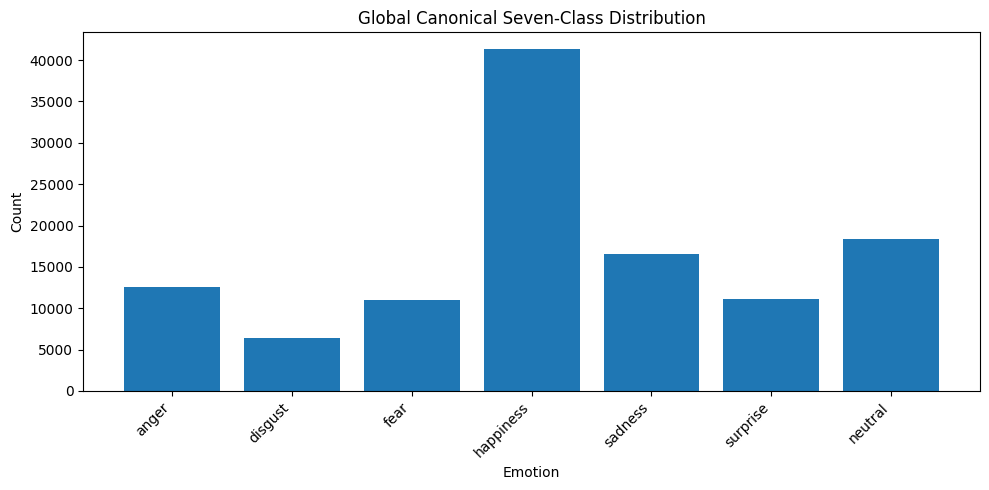

In [28]:
# =============================================================
# CELL 28 — GLOBAL CANONICAL DISTRIBUTION
# =============================================================

if not canonical_df.empty:

    global_distribution = (

        canonical_df
        .groupby(
            'Canonical_Emotion'
        )['Count']
        .sum()
        .reindex(
            CANONICAL_EMOTIONS,
            fill_value=0
        )
        .astype(int)

    )


    global_distribution_df = (
        global_distribution
        .reset_index()
    )


    global_distribution_df.columns = [
        'Emotion',
        'Count'
    ]


    display(
        global_distribution_df
    )


    plt.figure(
        figsize=(10, 5)
    )


    plt.bar(
        global_distribution_df['Emotion'],
        global_distribution_df['Count']
    )


    plt.title(
        'Global Canonical Seven-Class Distribution'
    )

    plt.xlabel(
        'Emotion'
    )

    plt.ylabel(
        'Count'
    )

    plt.xticks(
        rotation=45,
        ha='right'
    )

    plt.tight_layout()


    plt.savefig(

        os.path.join(
            PLOTS_DIR,
            'global_seven_class_distribution.png'
        ),

        dpi=150
    )


    plt.show()

else:

    print(
        "No canonical data available."
    )

In [29]:
# =============================================================
# CELL 29 — CLASS IMBALANCE ANALYSIS
# =============================================================

if not canonical_df.empty:

    counts = global_distribution

    total = counts.sum()


    imbalance_df = pd.DataFrame({

        'Emotion':
            counts.index,

        'Count':
            counts.values,

        'Percentage':
            (
                counts.values
                /
                total
                *
                100
            ).round(2)

    })


    max_count = counts.max()
    min_count = counts.min()


    imbalance_ratio = (

        max_count / min_count

        if min_count > 0

        else float('inf')

    )


    print(
        "Class imbalance ratio (max/min):",
        round(
            imbalance_ratio,
            3
        )
    )


    display(
        imbalance_df
    )


    imbalance_df.to_csv(

        os.path.join(
            REPORTS_DIR,
            'class_imbalance_analysis.csv'
        ),

        index=False

    )

Class imbalance ratio (max/min): 6.479


,Emotion,Count,Percentage
0,anger,12525,10.68
1,disgust,6372,5.43
2,fear,10956,9.34
3,happiness,41286,35.21
4,sadness,16579,14.14
5,surprise,11109,9.47
6,neutral,18419,15.71


In [30]:
# =============================================================
# CELL 30 — ANNOTATION COVERAGE
# =============================================================

coverage_df = verification_df[
    [
        'Dataset',
        'Total_Samples',
        'Annotated_Samples',
        'Canonical_Labeled_Samples',
        'Missing_Annotations',
        'Unsupported_Emotions',
        'Ambiguous_Samples',
        'Coverage_Percent'
    ]
].copy()


display(
    coverage_df
)


coverage_df.to_csv(

    os.path.join(
        REPORTS_DIR,
        'annotation_coverage.csv'
    ),

    index=False
)

,Dataset,Total_Samples,Annotated_Samples,Canonical_Labeled_Samples,Missing_Annotations,Unsupported_Emotions,Ambiguous_Samples,Coverage_Percent
0,CREMA-D,7442,7442,7442,0,0,0,100.00
1,RAVDESS,2880,2880,2880,0,0,0,100.00
2,SAVEE,480,480,480,0,0,0,100.00
3,TESS,2800,2800,2798,0,0,0,99.93
4,IEMOCAP,10218,10039,5680,179,4359,0,55.59
5,FER2013,35887,35887,35887,0,0,0,100.00
6,AffectNet,30626,30626,27755,0,2871,0,90.63
7,CK+,1962,1962,1854,0,108,0,94.50
8,RAF-DB,15339,15339,15339,0,0,0,100.00
9,GoEmotions,211225,211225,17131,0,194094,0,8.11


In [31]:
# =============================================================
# CELL 31 — SEVEN-CLASS COMPLETENESS CHECK
# =============================================================

if not emotion_matrix.empty:

    completeness_records = []


    for dataset_name in emotion_matrix.index:

        present = []
        missing = []


        for emotion in CANONICAL_EMOTIONS:

            count = emotion_matrix.loc[
                dataset_name,
                emotion
            ]


            if count > 0:

                present.append(
                    emotion
                )

            else:

                missing.append(
                    emotion
                )


        completeness_records.append({

            'Dataset':
                dataset_name,

            'Classes_Present':
                len(present),

            'Classes_Missing':
                len(missing),

            'Present':
                ', '.join(present),

            'Missing':
                ', '.join(missing)

        })


    completeness_df = pd.DataFrame(
        completeness_records
    )


    display(
        completeness_df
    )


    completeness_df.to_csv(

        os.path.join(
            REPORTS_DIR,
            'seven_class_completeness.csv'
        ),

        index=False
    )

,Dataset,Classes_Present,Classes_Missing,Present,Missing
0,AffectNet,7,0,"anger, disgust, fear, happiness, sadness, surp...",
1,CK+,6,1,"anger, disgust, fear, happiness, sadness, surp...",neutral
2,CREMA-D,6,1,"anger, disgust, fear, happiness, sadness, neutral",surprise
3,FER2013,7,0,"anger, disgust, fear, happiness, sadness, surp...",
4,GoEmotions,1,6,happiness,"anger, disgust, fear, sadness, surprise, neutral"
5,IEMOCAP,7,0,"anger, disgust, fear, happiness, sadness, surp...",
6,RAF-DB,7,0,"anger, disgust, fear, happiness, sadness, surp...",
7,RAVDESS,7,0,"anger, disgust, fear, happiness, sadness, surp...",
8,SAVEE,7,0,"anger, disgust, fear, happiness, sadness, surp...",
9,TESS,7,0,"anger, disgust, fear, happiness, sadness, surp...",


In [32]:
# =============================================================
# CELL 32 — FINAL PRE-PROCESSING GATE
# =============================================================

print("=" * 90)
print("FINAL PRE-PROCESSING GATE")
print("=" * 90)

required_active_datasets = [
    'CREMA-D',
    'RAVDESS',
    'SAVEE',
    'TESS',
    'IEMOCAP',
    'FER2013',
    'AffectNet',
    'CK+',
    'RAF-DB',
    'GoEmotions'
]

active_names = list(datasets_to_verify.keys())

if active_names != required_active_datasets:
    raise ValueError(
        "Active dataset registry mismatch.\n"
        f"Expected: {required_active_datasets}\n"
        f"Observed: {active_names}"
    )

assert 'SAMM' not in active_names, "SAMM must remain archived/optional."

# Required seven-class taxonomy.
assert set(CANONICAL_EMOTIONS) == {
    'anger', 'disgust', 'fear', 'happiness',
    'sadness', 'surprise', 'neutral'
}

# Every active dataset must have a verification report.
missing_reports = [
    d for d in required_active_datasets
    if d not in set(verification_df['Dataset'])
]

if missing_reports:
    raise ValueError(
        f"Missing verification reports: {missing_reports}"
    )

# GoEmotions must be genuinely row-based and usable as text.
go = verification_df[
    verification_df['Dataset'] == 'GoEmotions'
].iloc[0]

go_total = int(go['Total_Samples'])
go_canonical = int(go['Canonical_Labeled_Samples'])
go_unsupported = int(go['Unsupported_Emotions'])
go_ambiguous = int(go['Ambiguous_Samples'])
go_missing = int(go['Missing_Annotations'])

if go_total <= 0:
    raise ValueError("GoEmotions has zero logical text rows.")

if go_canonical <= 0:
    raise ValueError("GoEmotions has zero canonical seven-class rows.")

if (
    go_canonical
    + go_unsupported
    + go_ambiguous
    + go_missing
) != go_total:
    raise ValueError("GoEmotions row accounting failed at final gate.")

# All seven canonical classes must exist globally.
global_canonical = set(
    canonical_df['Canonical_Emotion'].dropna().astype(str).str.lower()
)

required_classes = {
    'anger', 'disgust', 'fear', 'happiness',
    'sadness', 'surprise', 'neutral'
}

missing_classes = required_classes - global_canonical

if missing_classes:
    raise ValueError(
        f"Global canonical class coverage failed: {sorted(missing_classes)}"
    )

# IEMOCAP accounting.
iem = verification_df[
    verification_df['Dataset'] == 'IEMOCAP'
].iloc[0]

iem_total = int(iem['Total_Samples'])
iem_accounted = (
    int(iem['Annotated_Samples'])
    + int(iem['Missing_Annotations'])
)

if iem_accounted != iem_total:
    raise ValueError(
        f"IEMOCAP annotation accounting failed: "
        f"{iem_accounted} != {iem_total}"
    )

# TESS corruption is allowed only as explicit exclusion.
tess = verification_df[
    verification_df['Dataset'] == 'TESS'
].iloc[0]

if int(tess['Canonical_Labeled_Samples']) > int(tess['Total_Samples']):
    raise ValueError("TESS canonical count exceeds total sample count.")

print("✓ Active dataset registry is correct.")
print("✓ Seven-class taxonomy is correct.")
print("✓ GoEmotions is active as row-based text data.")
print(f"✓ GoEmotions canonical rows: {go_canonical:,} / {go_total:,}")
print(f"✓ GoEmotions unsupported rows: {go_unsupported:,}")
print(f"✓ GoEmotions ambiguous rows: {go_ambiguous:,}")
print(f"✓ GoEmotions missing rows: {go_missing:,}")
print("✓ IEMOCAP accounting passed.")
print("✓ Global seven-class coverage passed.")
print("✓ SAMM is not in the active verification path.")
print("\nFINAL GATE: PASS — safe to proceed to metadata cleaning/splitting.")

FINAL PRE-PROCESSING GATE
✓ Active dataset registry is correct.
✓ Seven-class taxonomy is correct.
✓ GoEmotions is active as row-based text data.
✓ GoEmotions canonical rows: 17,131 / 211,225
✓ GoEmotions unsupported rows: 194,094
✓ GoEmotions ambiguous rows: 0
✓ GoEmotions missing rows: 0
✓ IEMOCAP accounting passed.
✓ Global seven-class coverage passed.
✓ SAMM is not in the active verification path.

FINAL GATE: PASS — safe to proceed to metadata cleaning/splitting.


In [33]:
# =============================================================
# CELL 33 — FINAL SANITY CHECKS
# =============================================================

print("=" * 90)
print("FINAL DATASET SANITY CHECKS")
print("=" * 90)

assert len(CANONICAL_EMOTIONS) == 7
assert len(CANONICAL_EMOTION_SET) == 7
print("✓ Seven-class vocabulary valid")

invalid_mappings = []

for dataset_name, mapping in DATASET_LABEL_MAP.items():

    for raw_label, canonical in mapping.items():

        if canonical is not None and canonical not in CANONICAL_EMOTION_SET:
            invalid_mappings.append({
                'Dataset': dataset_name,
                'Raw_Label': raw_label,
                'Canonical': canonical
            })

if invalid_mappings:
    display(pd.DataFrame(invalid_mappings))
    raise ValueError(
        "Invalid canonical mapping detected."
    )

print("✓ All canonical mappings valid")

assert 'SAMM' not in datasets_to_verify
assert 'SAMM' not in PARSERS
print("✓ SAMM excluded from active verification")

missing_datasets = [
    name
    for name, config in datasets_to_verify.items()
    if not os.path.exists(config['path'])
]

if missing_datasets:
    raise FileNotFoundError(
        f"Missing configured dataset folders: {missing_datasets}"
    )

print("✓ All configured dataset folders exist")

go_row_count = int(
    verification_df.loc[
        verification_df['Dataset'] == 'GoEmotions',
        'Total_Samples'
    ].sum()
)

if go_row_count <= 0:
    raise ValueError(
        "GoEmotions contains no logical rows."
    )

print(
    f"✓ GoEmotions logical rows detected: {go_row_count}"
)

canonical_total = int(
    verification_df['Canonical_Labeled_Samples'].sum()
)

if canonical_total <= 0:
    raise ValueError(
        "No canonical training samples detected."
    )

print(
    f"✓ Canonical labeled samples: {canonical_total}"
)

corrupted_total = int(
    verification_df['Corrupted_Files'].sum()
)

if corrupted_total > 0:
    print(
        f"⚠ Corrupted physical files requiring exclusion: "
        f"{corrupted_total}"
    )
else:
    print("✓ No integrity failures detected")

missing_annotations_total = int(
    verification_df['Missing_Annotations'].sum()
)

if missing_annotations_total > 0:
    print(
        f"⚠ Missing/unreadable annotations: "
        f"{missing_annotations_total}"
    )
else:
    print("✓ No missing annotations detected")

print("\nSanity checks complete.")


FINAL DATASET SANITY CHECKS
✓ Seven-class vocabulary valid
✓ All canonical mappings valid
✓ SAMM excluded from active verification
✓ All configured dataset folders exist
✓ GoEmotions logical rows detected: 211225
✓ Canonical labeled samples: 117246
⚠ Corrupted physical files requiring exclusion: 2
⚠ Missing/unreadable annotations: 179

Sanity checks complete.


In [34]:
# =============================================================
# CELL 34 — SAVE COMPLETE VERIFICATION CONFIGURATION
# =============================================================

verification_config = {
    'verification_version':
        'FINAL_V3_SCHEMA_AWARE_GOEMOTIONS_IEMOCAP_TESS_FIXED',

    'canonical_emotions':
        CANONICAL_EMOTIONS,

    'ravdess_calm_to_neutral':
        RAVDESS_CALM_TO_NEUTRAL,

    'iemocap_exc_to_happiness':
        IEMOCAP_EXC_TO_HAPPINESS,

    'dataset_label_map':
        DATASET_LABEL_MAP,

    'datasets':
        {
            name: {
                'path': config['path'],
                'type': config['type'],
                'format': config['format']
            }
            for name, config
            in datasets_to_verify.items()
        },

    'notes': {
        'CREMA-D':
            'Source taxonomy does not provide a separate surprise class.',

        'TESS':
            'Resolved to the actual inner TESS data tree to avoid counting a duplicated parent extraction.',

        'IEMOCAP':
            'Audio and video are both active when physical files exist; unsupported XXX/FRU/OTH labels remain excluded.',

        'GoEmotions':
            'Schema-aware row parser; supports numeric IDs, names, serialized lists, and multi-label rows. Rows mapping to one canonical class are accepted; conflicting canonical classes are ambiguous; unsupported-only rows remain excluded.',

        'SAMM':
            'Archived/optional and excluded from active static verification.',

        'Integrity':
            'Corrupted files are never counted as usable canonical samples.'
    }
}

with open(
    os.path.join(
        REPORTS_DIR,
        'verification_configuration.json'
    ),
    'w',
    encoding='utf-8'
) as f:
    json.dump(
        verification_config,
        f,
        indent=4
    )

print("✓ Complete verification configuration saved.")


✓ Complete verification configuration saved.


In [35]:
# =============================================================
# CELL 35 — FINAL REPORT
# =============================================================

print("\n")
print("=" * 90)
print("FINAL DATA VERIFICATION COMPLETE")
print("=" * 90)

print("\nDatasets processed:", len(datasets_to_verify))
print("Canonical classes:", len(CANONICAL_EMOTIONS))
print("Total physical files:", int(verification_df['Total_Files'].sum()))
print("Total logical samples:", int(verification_df['Total_Samples'].sum()))
print("Corrupted files:", int(verification_df['Corrupted_Files'].sum()))
print("Missing annotations:", int(verification_df['Missing_Annotations'].sum()))
print("Unsupported labels:", int(verification_df['Unsupported_Emotions'].sum()))
print("Ambiguous samples:", int(verification_df['Ambiguous_Samples'].sum()))
print("Canonical labeled samples:", int(verification_df['Canonical_Labeled_Samples'].sum()))

print("\n" + "=" * 90)
print("FINAL DATASET STATUS")
print("=" * 90)

for _, row in verification_df.iterrows():
    dataset = row['Dataset']

    if row['Folder_Structure'] != 'Valid':
        status = "❌ FAIL — DATASET PATH"
    elif dataset == 'GoEmotions':
        if row['Canonical_Labeled_Samples'] > 0:
            status = (
                "✓ VERIFIED — TEXT ACTIVE; "
                "EXPLICIT SEVEN-CLASS FILTERING"
            )
        else:
            status = "❌ FAIL — NO CANONICAL GOEMOTIONS SAMPLES"
    elif row['Corrupted_Files'] > 0:
        status = (
            "⚠️ VERIFIED — CORRUPTED FILES EXCLUDED"
        )
    elif row['Unsupported_Emotions'] > 0:
        status = (
            "✓ VERIFIED — EXPLICIT UNSUPPORTED-LABEL EXCLUSIONS"
        )
    else:
        status = "✓ VERIFIED"

    print(f"{dataset:15s} : {status}")

print("\n" + "=" * 90)
print("GENERATED REPORTS")
print("=" * 90)

important_files = [
    'verification_summary.csv',
    'verification_summary.json',
    'raw_label_report.csv',
    'canonical_emotion_distribution.csv',
    'unsupported_emotions.csv',
    'detailed_verification_log.csv',
    'dataset_emotion_matrix.csv',
    'class_imbalance_analysis.csv',
    'annotation_coverage.csv',
    'seven_class_completeness.csv',
    'ravdess_harmonization_policy.csv',
    'verification_configuration.json',
    'goemotions_schema_inspection.csv',
    'goemotions_raw_labels.csv',
    'goemotions_annotation_columns.csv',
    'goemotions_parser_file_report.csv',
    'goemotions_row_diagnostics.csv'
]

for filename in important_files:
    path = os.path.join(REPORTS_DIR, filename)
    if os.path.exists(path):
        print("  ✓", filename)

print("\n" + "=" * 90)
print("VERIFICATION PIPELINE FINISHED")
print("=" * 90)

print(
    "\nFINAL STATUS: PASS — proceed to metadata cleaning and splitting."
)

print(
    "GoEmotions is active as text. IEMOCAP is active. "
    "SAMM remains archived/optional."
)



FINAL DATA VERIFICATION COMPLETE

Datasets processed: 10
Canonical classes: 7
Total physical files: 107637
Total logical samples: 318859
Corrupted files: 2
Missing annotations: 179
Unsupported labels: 201432
Ambiguous samples: 0
Canonical labeled samples: 117246

FINAL DATASET STATUS
CREMA-D         : ✓ VERIFIED
RAVDESS         : ✓ VERIFIED
SAVEE           : ✓ VERIFIED
TESS            : ⚠️ VERIFIED — CORRUPTED FILES EXCLUDED
IEMOCAP         : ✓ VERIFIED — EXPLICIT UNSUPPORTED-LABEL EXCLUSIONS
FER2013         : ✓ VERIFIED
AffectNet       : ✓ VERIFIED — EXPLICIT UNSUPPORTED-LABEL EXCLUSIONS
CK+             : ✓ VERIFIED — EXPLICIT UNSUPPORTED-LABEL EXCLUSIONS
RAF-DB          : ✓ VERIFIED
GoEmotions      : ✓ VERIFIED — TEXT ACTIVE; EXPLICIT SEVEN-CLASS FILTERING

GENERATED REPORTS
  ✓ verification_summary.csv
  ✓ verification_summary.json
  ✓ raw_label_report.csv
  ✓ canonical_emotion_distribution.csv
  ✓ unsupported_emotions.csv
  ✓ detailed_verification_log.csv
  ✓ dataset_emotion_matr